# Lab 3 Task 2: 4-PAM Pulse Shaping and Matched Filtering

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

def locate_lab_root():
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / "support" / "lab3_tools.py").is_file():
            return base
    raise FileNotFoundError("Open this notebook from its Lab 3 folder.")

LAB_ROOT = locate_lab_root()
sys.path.insert(0, str(LAB_ROOT / "support"))
WORK_DIR = LAB_ROOT / "work"
FIGURE_DIR = WORK_DIR / "figures"
WAVEFORM_DIR = WORK_DIR / "waveforms"
CAPTURE_DIR = WORK_DIR / "captures"
for path in (FIGURE_DIR, WAVEFORM_DIR, CAPTURE_DIR):
    path.mkdir(parents=True, exist_ok=True)
print("Lab root:", LAB_ROOT)

Lab root: /home/sneill/ECE7377


In [2]:
from scipy import special
from lab3_dsp import rrc_taps
from lab3_tools import plot_pam_chain, plot_pam_eye

order = 4
symbol_count = 20_000
samples_per_symbol = 4
rolloff = 0.35
span_symbols = 10
ebn0_db = 10.0
rng = np.random.default_rng(303)
labels = rng.integers(0, order, symbol_count)

# To Do: normalized 4-PAM levels indexed by labels 0, 1, 2, 3.
levels = (2 * np.arange(order) - 3) / np.sqrt(5)
symbols = levels[labels]

# To Do: insert L-1 zeros between adjacent symbols.
upsampled = np.zeros(symbol_count * samples_per_symbol)
upsampled[::samples_per_symbol] = symbols

taps = rrc_taps(rolloff, samples_per_symbol, span_symbols)
transmitted = np.convolve(upsampled, taps)

bits_per_symbol = int(np.log2(order))
gamma_b = 10**(ebn0_db/10)
# To Do: derive Eb, N0, and the real noise variance.
symbol_energy = 1.0
bit_energy = symbol_energy / bits_per_symbol
n0 = bit_energy / gamma_b
noise_variance = n0 / 2

received = transmitted + rng.normal(0, np.sqrt(noise_variance), transmitted.size)
matched = np.convolve(received, taps)

# To Do: derive the two-filter delay and correct decision indices.
one_filter_delay = (len(taps) - 1) // 2
cascade_delay = 2 * one_filter_delay
decision_indices = (cascade_delay + np.arange(symbol_count) * samples_per_symbol)
decisions = matched[decision_indices]

# To Do: nearest-level detection, SER, and RMS EVM.
detected = np.argmin(np.abs(decisions[:, None] - levels[None, :])**2, axis=1)
ser = np.mean(detected != labels)
evm = np.sqrt(np.sum(np.abs(decisions - symbols)**2) / np.sum(np.abs(symbols)**2))

In [3]:
assert np.isclose(np.mean(levels**2), 1.0)
assert len(taps) == 41
assert cascade_delay == 40
assert np.isclose(noise_variance, 0.025)
argument = np.sqrt(6*bits_per_symbol*gamma_b/(order**2 - 1))
theoretical_ser = 2*(order-1)/order * 0.5*special.erfc(argument/np.sqrt(2))
print(f"SER measured/theory: {ser:.6f} / {theoretical_ser:.6f}")
print(f"RMS EVM: {100*evm:.3f}%")

SER measured/theory: 0.004100 / 0.003508
RMS EVM: 15.889%


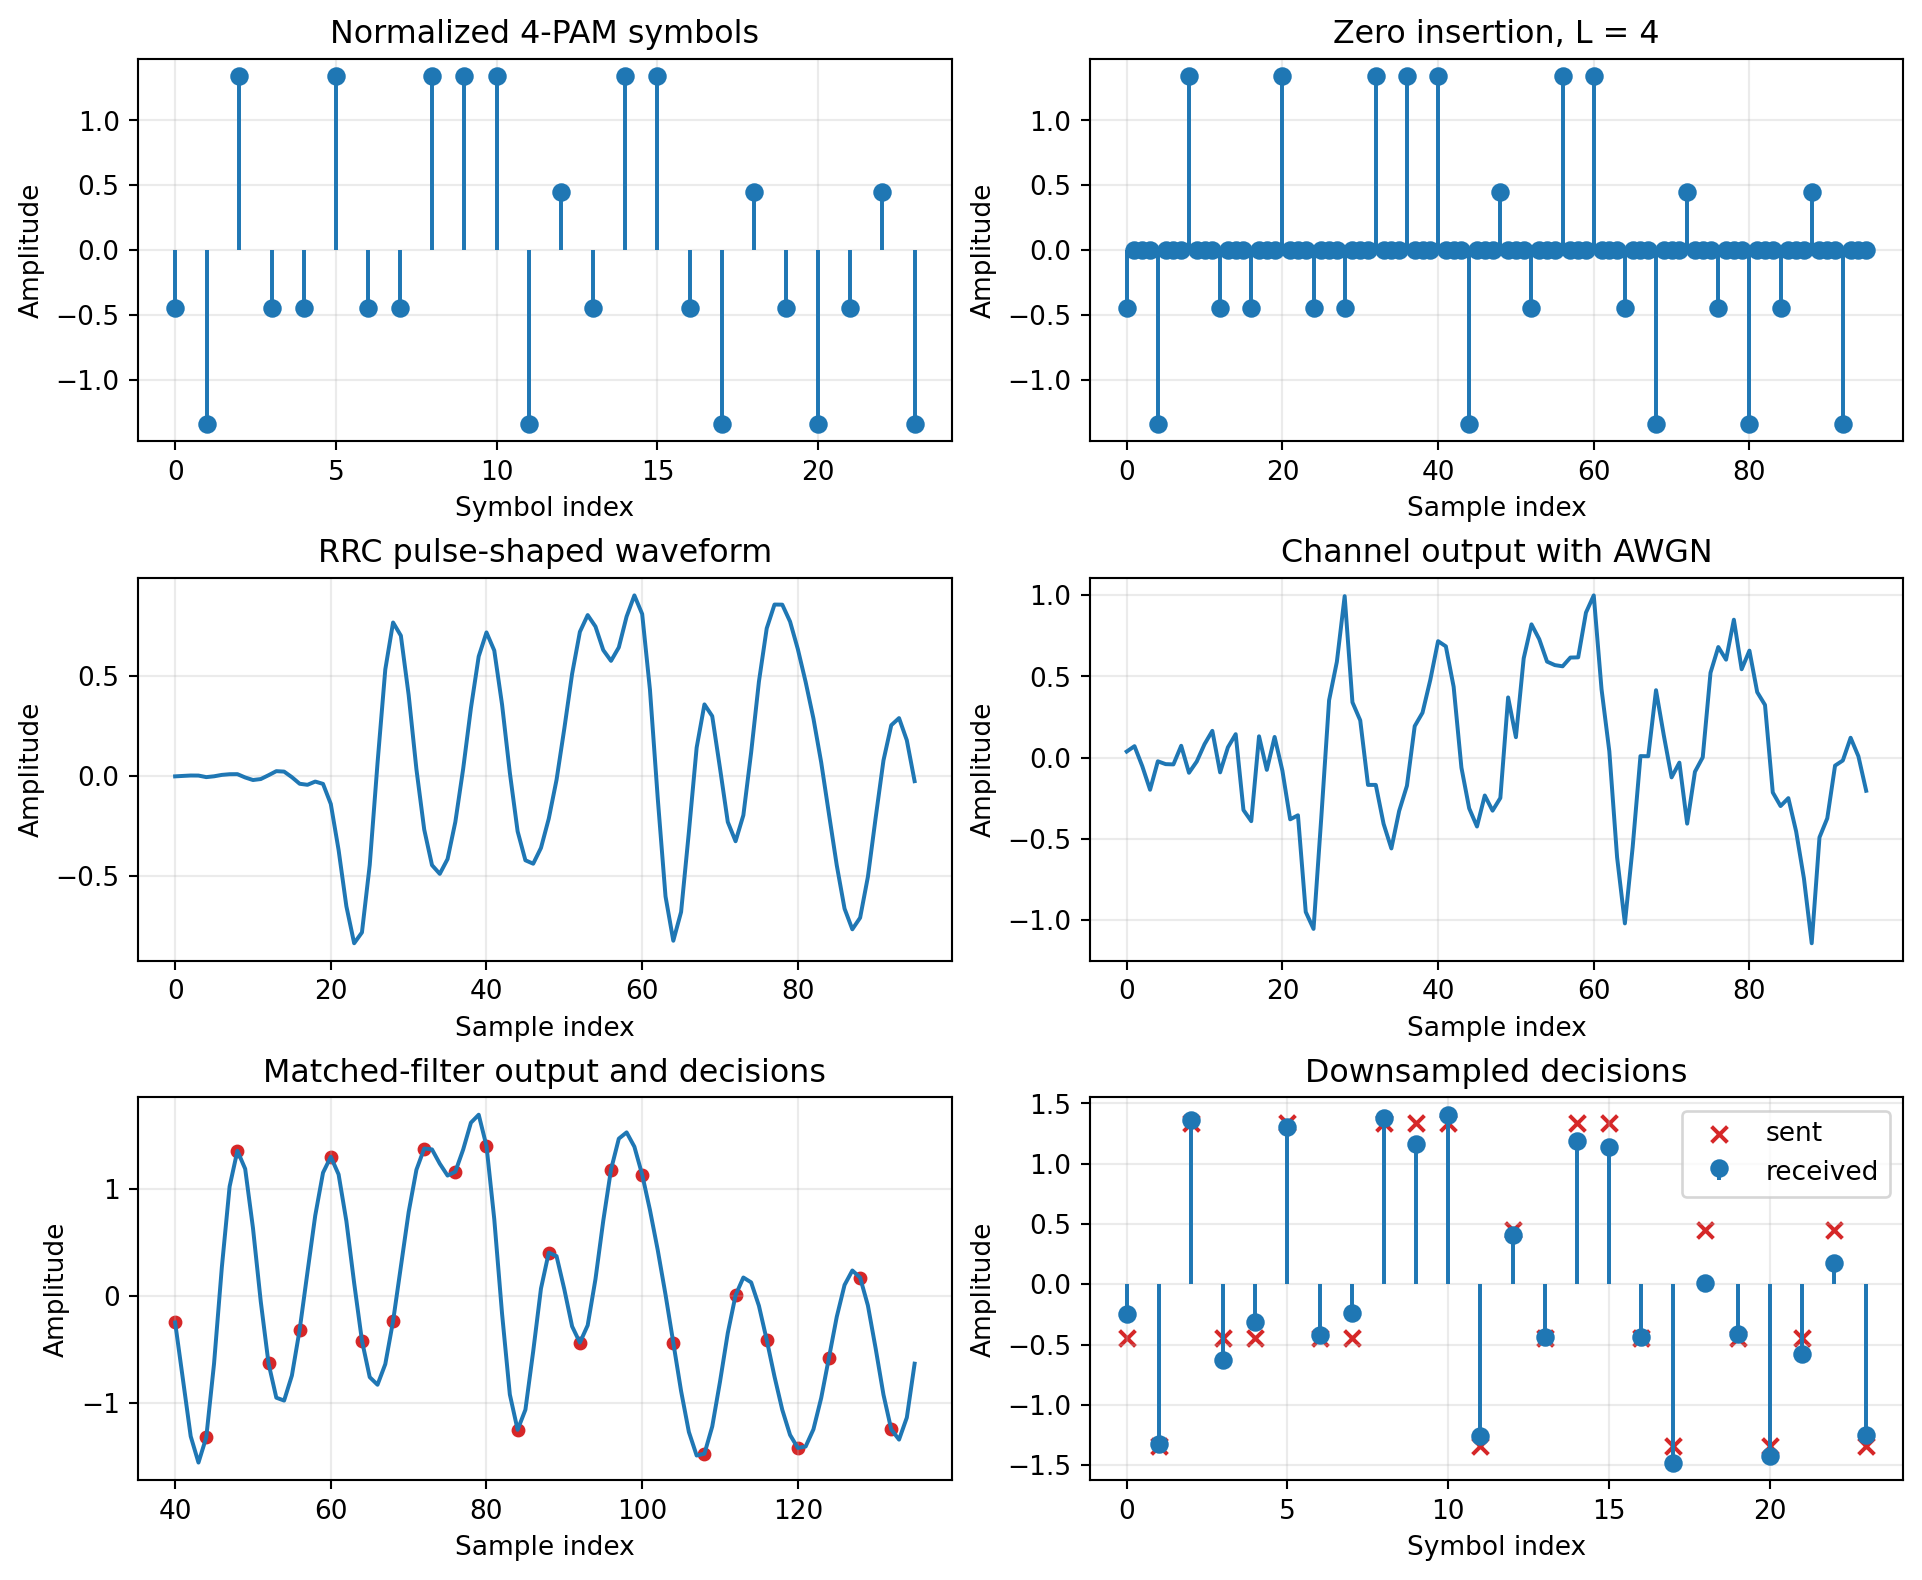

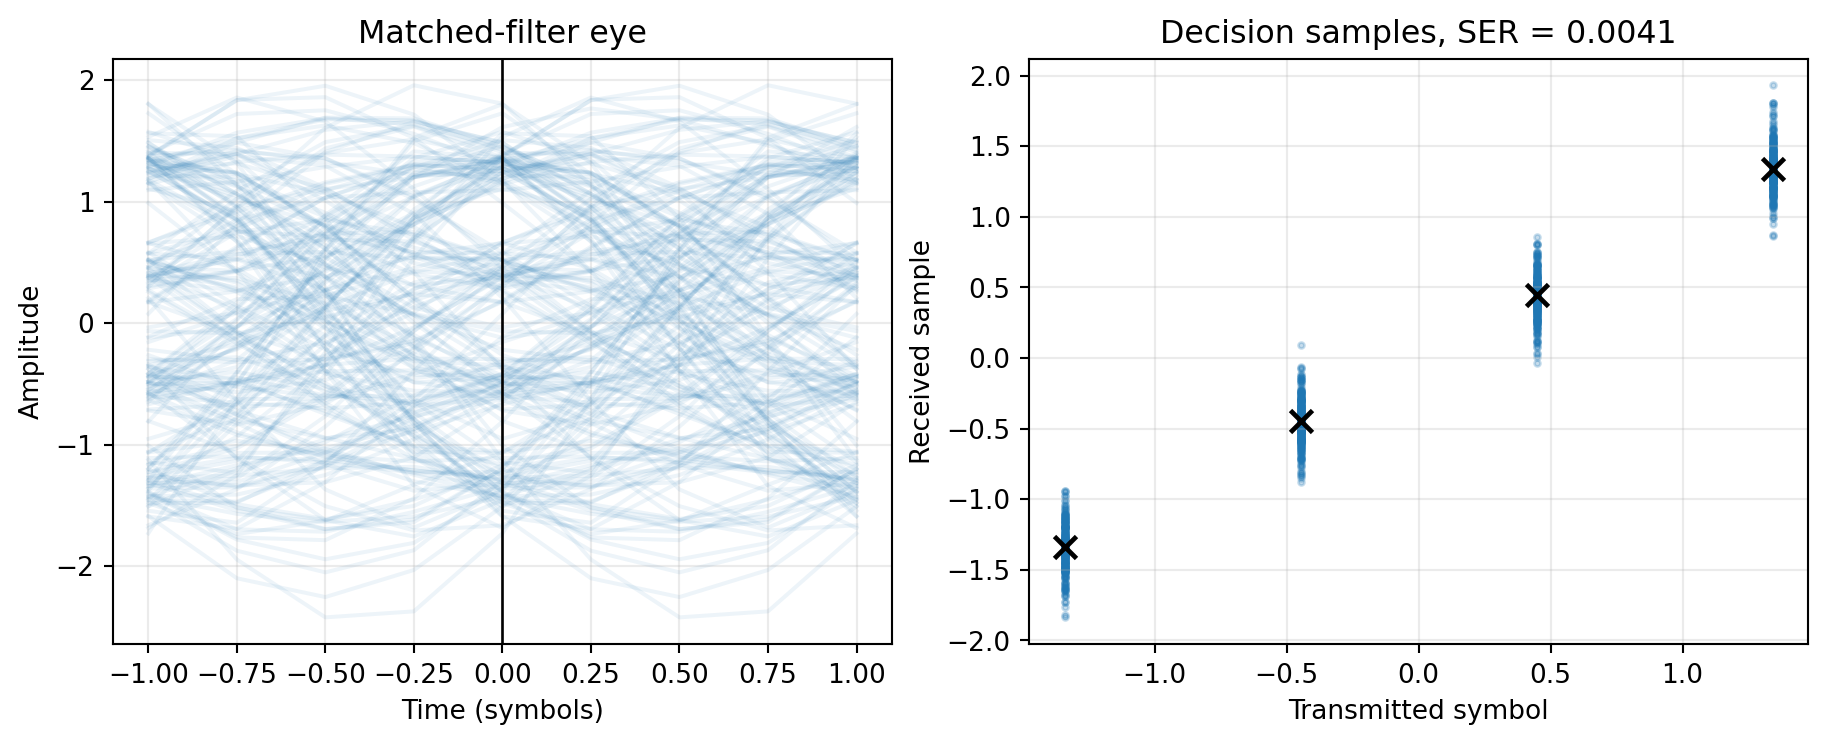

In [4]:
chain_figure = plot_pam_chain(
    symbols, upsampled, transmitted, received, matched,
    decision_indices, decisions, samples_per_symbol, FIGURE_DIR
)
eye_figure = plot_pam_eye(
    symbols, matched, decision_indices, decisions, levels,
    samples_per_symbol, ser, FIGURE_DIR
)
display(Image(filename=str(chain_figure)))
display(Image(filename=str(eye_figure)))

<span style="color:#165696"><b>Report.</b> Show the 4-PAM energy, zero-insertion operation, both filter delays, Eb, N0, noise variance, measured and theoretical SER, and EVM. Explain the Nyquist samples, correct downsampling phase, and why the matched filter is used.</span>